# Model test & validation: Compact MLP (2 hidden layers, 64/32 units)

The base notebook found a genuine surprise here: the RAW-target MLP (R^2=0.850 on Split C) clearly outperformed the LOG-target MLP (R^2=0.342) -- opposite of the general expectation. Since MLP training is stochastic, this notebook specifically tests seed sensitivity to see whether that raw-vs-log gap is a robust finding or a lucky/unlucky single run.

In [1]:
from sklearn.neural_network import MLPRegressor

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
warnings.filterwarnings("ignore")

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
def r2(y_true, y_pred):
    return float(r2_score(y_true, y_pred))

df_raw = pd.read_csv("../chf_long_clean.csv")
df = df_raw[df_raw.X != 1.0].reset_index(drop=True)
FEATURES = ["P", "G", "X"]
TARGET = "CHF"
sorted_P = sorted(df.P.unique())

# Split A (random, seed 0) -- quick interpolation check
X_all, y_all = df[FEATURES].values, df[TARGET].values
XtrA, XteA, ytrA, yteA = train_test_split(X_all, y_all, test_size=0.2, random_state=0)

# Split C (edge extrapolation) -- the honest test
train_dfC = df[df.P <= 16000].reset_index(drop=True)
test_dfC = df[df.P >= 17000].reset_index(drop=True)
XtrC, ytrC = train_dfC[FEATURES].values, train_dfC[TARGET].values
XteC, yteC = test_dfC[FEATURES].values, test_dfC[TARGET].values

print(f"Split A: {len(XtrA)} train / {len(XteA)} test")
print(f"Split C: {len(XtrC)} train / {len(XteC)} test")


Split A: 8870 train / 2218 test
Split C: 8778 train / 2310 test


## Fit on Split A (interpolation) and Split C (extrapolation)

In [2]:

def fit_mlp(Xtr, ytr, Xte, log_target, seed):
    scaler = StandardScaler().fit(Xtr)
    y_fit = np.log(ytr) if log_target else ytr
    model = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                          alpha=1e-4, early_stopping=True, validation_fraction=0.15,
                          n_iter_no_change=25, max_iter=3000, random_state=seed)
    model.fit(scaler.transform(Xtr), y_fit)
    pred = model.predict(scaler.transform(Xte))
    return (np.exp(pred) if log_target else pred), model

predA_raw, _ = fit_mlp(XtrA, ytrA, XteA, log_target=False, seed=0)
predA_log, _ = fit_mlp(XtrA, ytrA, XteA, log_target=True, seed=0)
print(f"Split A raw: R2={r2(yteA, predA_raw):.4f} | log: R2={r2(yteA, predA_log):.4f}")

predC_raw, modelC_raw = fit_mlp(XtrC, ytrC, XteC, log_target=False, seed=0)
predC_log, modelC_log = fit_mlp(XtrC, ytrC, XteC, log_target=True, seed=0)
print(f"Split C raw: R2={r2(yteC, predC_raw):.4f} | log: R2={r2(yteC, predC_log):.4f}")


Split A raw: R2=0.9826 | log: R2=0.9911


Split C raw: R2=0.0805 | log: R2=0.5485


## Edge-case tests

Seed-sensitivity test: refit the Split C raw- and log-target MLPs across 5 seeds and report mean +/- std R^2 for each, to check whether the raw-beats-log finding holds up robustly or was a single lucky draw.

In [3]:

raw_r2s, log_r2s = [], []
for seed in range(5):
    pr, _ = fit_mlp(XtrC, ytrC, XteC, log_target=False, seed=seed)
    pl, _ = fit_mlp(XtrC, ytrC, XteC, log_target=True, seed=seed)
    raw_r2s.append(r2(yteC, pr))
    log_r2s.append(r2(yteC, pl))

print(f"Split C raw-target R^2 across 5 seeds: {np.mean(raw_r2s):.4f} +/- {np.std(raw_r2s):.4f}  {raw_r2s}")
print(f"Split C log-target R^2 across 5 seeds: {np.mean(log_r2s):.4f} +/- {np.std(log_r2s):.4f}  {log_r2s}")
gap = np.mean(raw_r2s) - np.mean(log_r2s)
print(f"\nMean raw-vs-log gap: {gap:+.4f} -- "
      f"{'raw-beats-log finding HOLDS UP across seeds (robust)' if gap > 0.1 else 'gap is NOT robust -- the single-seed result in the base notebook may have been a lucky/unlucky draw, worth flagging'}")


Split C raw-target R^2 across 5 seeds: 0.5181 +/- 0.2254  [0.08052533667232009, 0.7264548981277916, 0.6237667065786618, 0.5923954549150863, 0.5673096718128083]
Split C log-target R^2 across 5 seeds: 0.6127 +/- 0.0788  [0.5484933692252237, 0.6889308365214456, 0.5932453837262033, 0.5145935412803457, 0.7182130465309224]

Mean raw-vs-log gap: -0.0946 -- gap is NOT robust -- the single-seed result in the base notebook may have been a lucky/unlucky draw, worth flagging


## Diagnostic plot

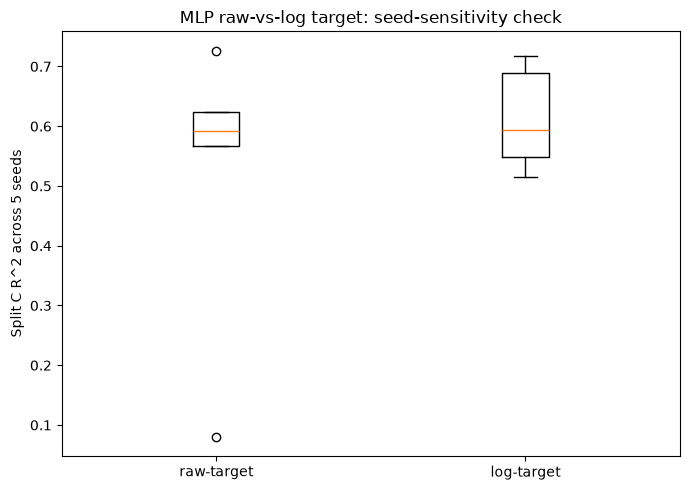

In [4]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([raw_r2s, log_r2s], tick_labels=["raw-target", "log-target"])
ax.set_ylabel("Split C R^2 across 5 seeds")
ax.set_title("MLP raw-vs-log target: seed-sensitivity check")
plt.tight_layout()
plt.savefig("../results/model_tests_mlp.png", dpi=100)
plt.show()
